# Kenapa Credit Risk Penting?

Analisis risiko kredit merupakan aspek krusial dalam industri perbankan dan pembiayaan. Ketika institusi keuangan memberikan pinjaman, tidak ada jaminan absolut bahwa dana tersebut akan dikembalikan, bahkan nasabah dengan profil yang tampak baik sekalipun dapat memiliki faktor risiko tersembunyi yang meningkatkan kemungkinan gagal bayar ***default***. Konsekuensi dari kesalahan prediksi tidak simetris. Menyetujui pinjaman kepada nasabah pada akhirnya ***default*** berarti kehilangan seluruh pokok pinjaman, sedangkan menolak nasabah yang sebenarnya mampu membayar hanya berarti kehilangan potensi keuntungan. Hoffmann (1994) dalam German Credit Dataset mengkuantifikasi asimetri ini melalui cost matrix: biaya salah mengklasifikasikan nasabah buruk sebagai baik 5 kali lebih besar dibandingkan sebaliknya.

Berdasarkan kerangka cost tersebut, proyek ini bertujuan untuk meminimalkan total kerugian klasifikasi dari German Credit Dataset dengan membandingkan dua pendekatan model (**Logistic Regression** dan **Random Forest**) menggunakan cost metric yang mengacu langsung pada rekomendasi dataset.

# Exploratory Data Analysis

## Load & Splitting Dataset

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

col_name = [
      'status', 'duration', 'credit_hist', 'purpose', 'amount', 'savings', 'employment', 'install_rate', 'personal_status', 'debtors', 'residence', 'property', 'age', 'install_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'telephone', 'foreign', 'label'
]

df = pd.read_csv('statlog/german.data', sep=r'\s+', names=col_name, header=None)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   status            1000 non-null   str  
 1   duration          1000 non-null   int64
 2   credit_hist       1000 non-null   str  
 3   purpose           1000 non-null   str  
 4   amount            1000 non-null   int64
 5   savings           1000 non-null   str  
 6   employment        1000 non-null   str  
 7   install_rate      1000 non-null   int64
 8   personal_status   1000 non-null   str  
 9   debtors           1000 non-null   str  
 10  residence         1000 non-null   int64
 11  property          1000 non-null   str  
 12  age               1000 non-null   int64
 13  install_plans     1000 non-null   str  
 14  housing           1000 non-null   str  
 15  existing_credits  1000 non-null   int64
 16  job               1000 non-null   str  
 17  num_dependents    1000 non-null   int64
 18  

Output dari `df.info()` menunjukkan tidak ada nilai yang hilang, sehingga tidak perlu menghandle missing value

### Penjelasan kelas untuk setiap kolom kategorikal

##### 1. Status (Likuiditas Jangka Pendek)

Menggambarkan saldo di rekening giro nasabah pada saat pengajuan.

* **A11**: < 0 DM (Saldo negatif/minus)
* **A12**: 0 <= ... < 200 DM (Saldo rendah)
* **A13**: >= 200 DM / Gaji masuk tetap (Saldo stabil)
* **A14**: Tidak memiliki rekening giro

##### 2. Savings (Tabungan)

Menggambarkan cadangan dana likuid jangka panjang (dana darurat).

* **A61**: < 100 DM
* **A62**: 100 <= ... < 500 DM
* **A63**: 500 <= ... < 1000 DM
* **A64**: >= 1000 DM
* **A65**: Tidak diketahui / tidak memiliki tabungan

##### 3. Credit_hist (Kedisiplinan Membayar)

Rekam jejak perilaku pembiayaan sebelumnya.

* **A30**: Belum pernah ambil kredit / Semua terbayar tepat waktu
* **A31**: Semua kredit di bank ini terbayar tepat waktu
* **A32**: Kredit yang ada terbayar tepat waktu sampai saat ini
* **A33**: Pernah terlambat membayar di masa lalu
* **A34**: Akun kritis / Ada kredit di tempat lain

##### 4. Purpose (Tujuan Pinjaman)

Niat penggunaan dana pinjaman.

* **A40**: Mobil (Baru) | **A41**: Mobil (Bekas)
* **A42**: Furnitur/Peralatan | **A43**: Radio/Televisi
* **A44**: Alat Rumah Tangga | **A45**: Perbaikan (Repairs)
* **A46**: Pendidikan | **A48**: Pelatihan Ulang (Retraining)
* **A49**: Bisnis | **A410**: Lain-lain

##### 5. Employment (Pengalaman Kerja)
Stabilitas penghasilan berdasarkan masa kerja.

* **A71**: Menganggur (Unemployed)
* **A72**: < 1 tahun
* **A73**: 1 <= ... < 4 tahun
* **A74**: 4 <= ... < 7 tahun
* **A75**: >= 7 tahun

##### 6. Property (Aset Properti)

Aset tetap yang dimiliki sebagai jaminan terselubung.

* **A121**: Real Estate (Rumah/Tanah)
* **A122**: Tabungan bangunan / Asuransi jiwa
* **A123**: Mobil atau aset lainnya
* **A124**: Tidak diketahui / tidak punya properti

##### 7. Housing (Biaya Hidup Tetap)

Kondisi tempat tinggal yang memengaruhi beban pengeluaran.

* **A151**: Sewa (Rent)
* **A152**: Milik Sendiri (Own)
* **A153**: Gratis / Tanpa biaya (For free)

##### 8. Install_plans (Cicilan di Tempat Lain)

Komitmen keuangan nasabah pada institusi lain.

* **A141**: Ada cicilan di Bank lain
* **A142**: Ada cicilan di Toko (Stores)
* **A143**: Tidak ada cicilan lain

##### 9. Label

* **0**: Nasabah baik
* **1**: Nasabah buruk


## Analisis Univariate

### Distribusi Target

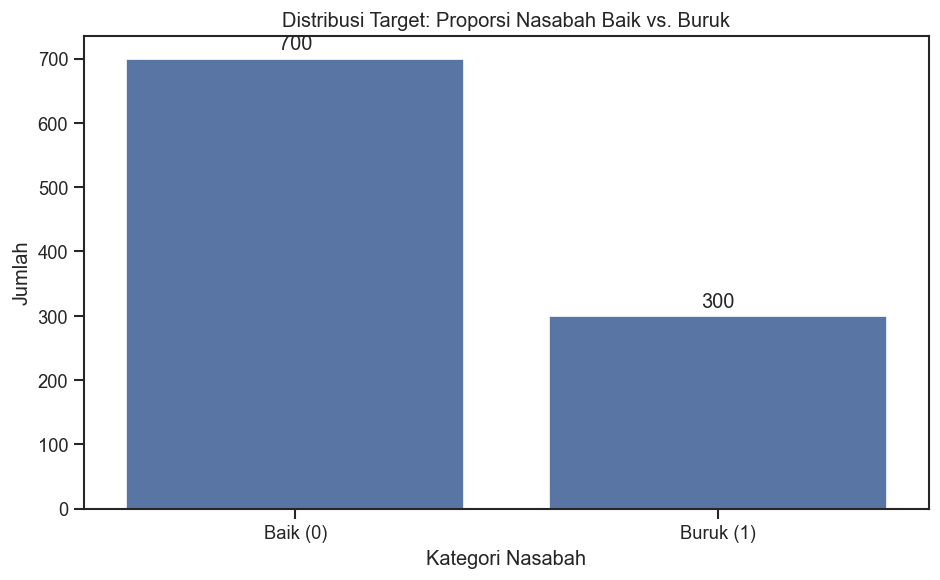

In [54]:
# Mapping label target, baik = 0, buruk = 1
df['label'] = df['label'].map({1: 0, 2: 1})

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.autolayout'] = True

ax = sns.countplot(data=df, x='label')

for container in ax.containers:
    ax.bar_label(container, padding=3) # type: ignore
plt.title('Distribusi Target: Proporsi Nasabah Baik vs. Buruk')
plt.xlabel('Kategori Nasabah', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Baik (0)', 'Buruk (1)'])
plt.show()

Hasil analisis univariat menunjukkan adanya masalah ketidakseimbangan data dengan proporsi: 

* **Kelas 0 (Nasabah Baik):** 700 data
* **Kelas 1 (Nasabah Buruk):** 300 data

Ketidakseimbangan proporsi ini menyebabkan model mengalami **bias**. Model akan cenderung lebih dominan memprediksi nasabah ke dalam kelas mayoritas (Kelas 0) dan kesulitan untuk mengidentifikasi karakteristik nasabah pada kelas minoritas (Kelas 1/gagal bayar).

Untuk mengatasi masalah ini, proyek ini akan menerapkan pendekatan **Class Weight** saat melatih model karena kita akan mempertahankan seluruh informasi asli tanpa perlu membuang data penting (*undersampling*) atau mensintesis data baru(*oversampling*).

## Multivariate Analysis

### Numerical Features

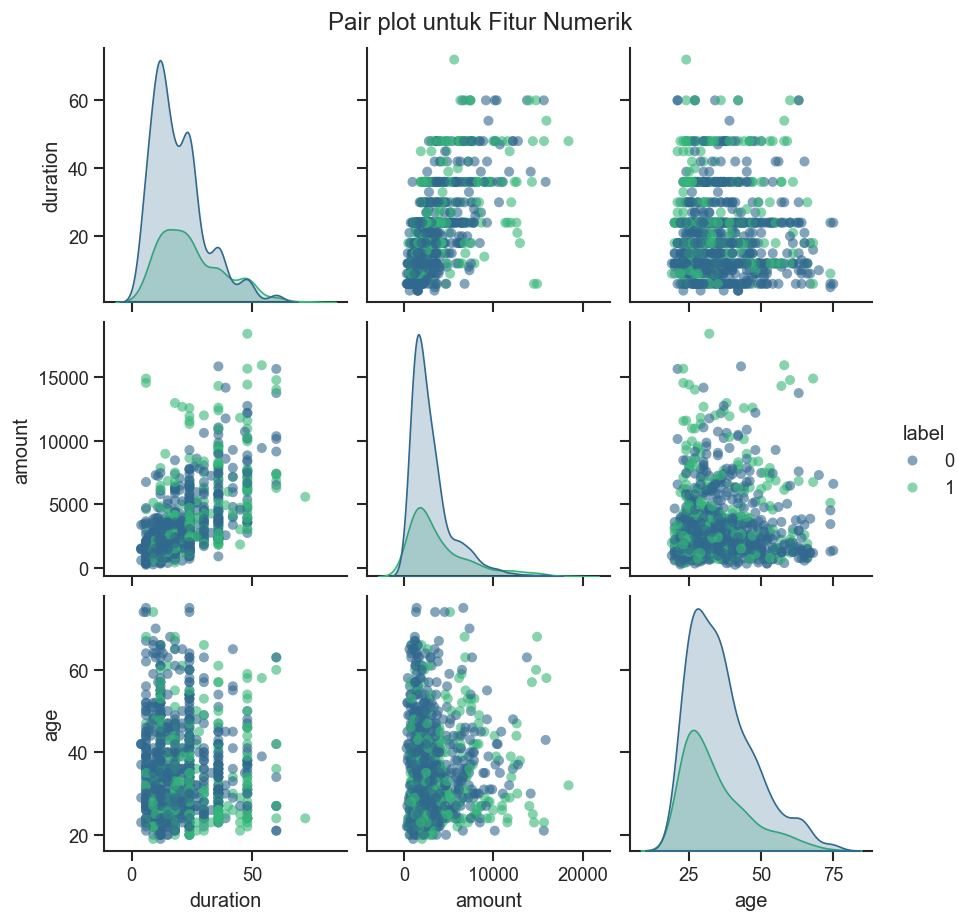

In [55]:
num_cat = ['duration', 'amount', 'age']
sns.set_theme(style='ticks')
pair_plot = sns.pairplot(
    df[['duration', 'amount', 'age', 'label']],
    hue='label',
    palette='viridis',
    diag_kind='kde',
    plot_kws={
        'alpha': 0.6,
        'edgecolor': 'none'
    }
)

pair_plot.figure.suptitle('Pair plot untuk Fitur Numerik', y=1.02)
plt.show()

#### Key Insights

1. Terdapat hubungan linear positif yang jelas antara jumlah pinjaman (`amount`) dengan tenor (`duration`)
2. Variabel `age` cenderung membentuk pola acak terhadap `amount` maupun `duration`. Hal ini mengindikasikan bahwa usia nasabah tidak memiliki hubungan linear secara langsung
3. Ketiga variabel numerikal (`duration`, `amount`, dan `age`) menunjukkan distribusi yang miring ke kanan


#### pointbiserialr

In [56]:
from scipy.stats import pointbiserialr

num_analysis = []

for col in num_cat:
    corr, p_val = pointbiserialr(df[col], df['label'])
    skew = df[col].skew()
    num_analysis.append({'feature': col, 'correlation': corr, 'p_value': p_val, 'skew': skew})
num_df = pd.DataFrame(num_analysis)
num_df.sort_values(by='correlation', ascending=False)


,feature,correlation,p_value,skew
0,duration,0.214927,6.488050e-12,1.094184
1,amount,0.154739,8.797572e-07,1.949628
2,age,-0.091127,3.925339e-03,1.020739


Hasil analisis korelasi Point-Biserial menunjukkan `duration` pinjaman memiliki korelasi positif terkuat (r $\approx 0.21$, p < 0,001) diikuti oleh jumlah pinjaman (`amount`) sebesar 0.15, sementara usia memiliki korelasi negatif yang lebih lemah(r $\approx$-0.09). Hal ini mengindikasikan:
1. Semakin besar tenor dan semakin besar nominal kredit yang dicairkan, probabilitas nasabah mengalami gagal bayar semakin besar
2. Peningkatan usia secara moderat berkorelasi dengan penurunan risiko default, mengindikasikan kematangan finansial dan akumulasi aset yang lebih stabil seiring bertambahnya usia

### Uji Korelasi antar fitur

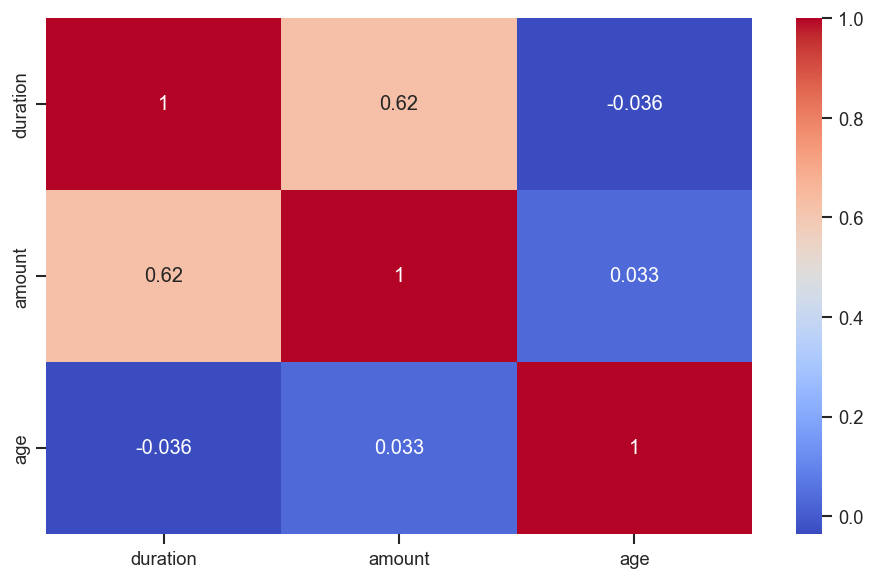

In [57]:
sns.heatmap(df[num_cat].corr(), cmap='coolwarm', annot=True)
plt.show()

Ditemukan korelasi positif (0.62) antara durasi pinjaman dengan jumlah yang dipinjamkan. Hubungan ini mencerminkan jumlah uang yang dipinjamkan membesar mengharuskan perpanjangan tenor pelunasan. Nilai 0.62 dinilai belum melampaui ambang batas kolinearitas kritis (umumnya 0.7-0.9) yang dapat menyebabkan bias dalam training model regresi logistik. Oleh karena itu, kedua fitur ini dipertahankan.

### Categorical Feature

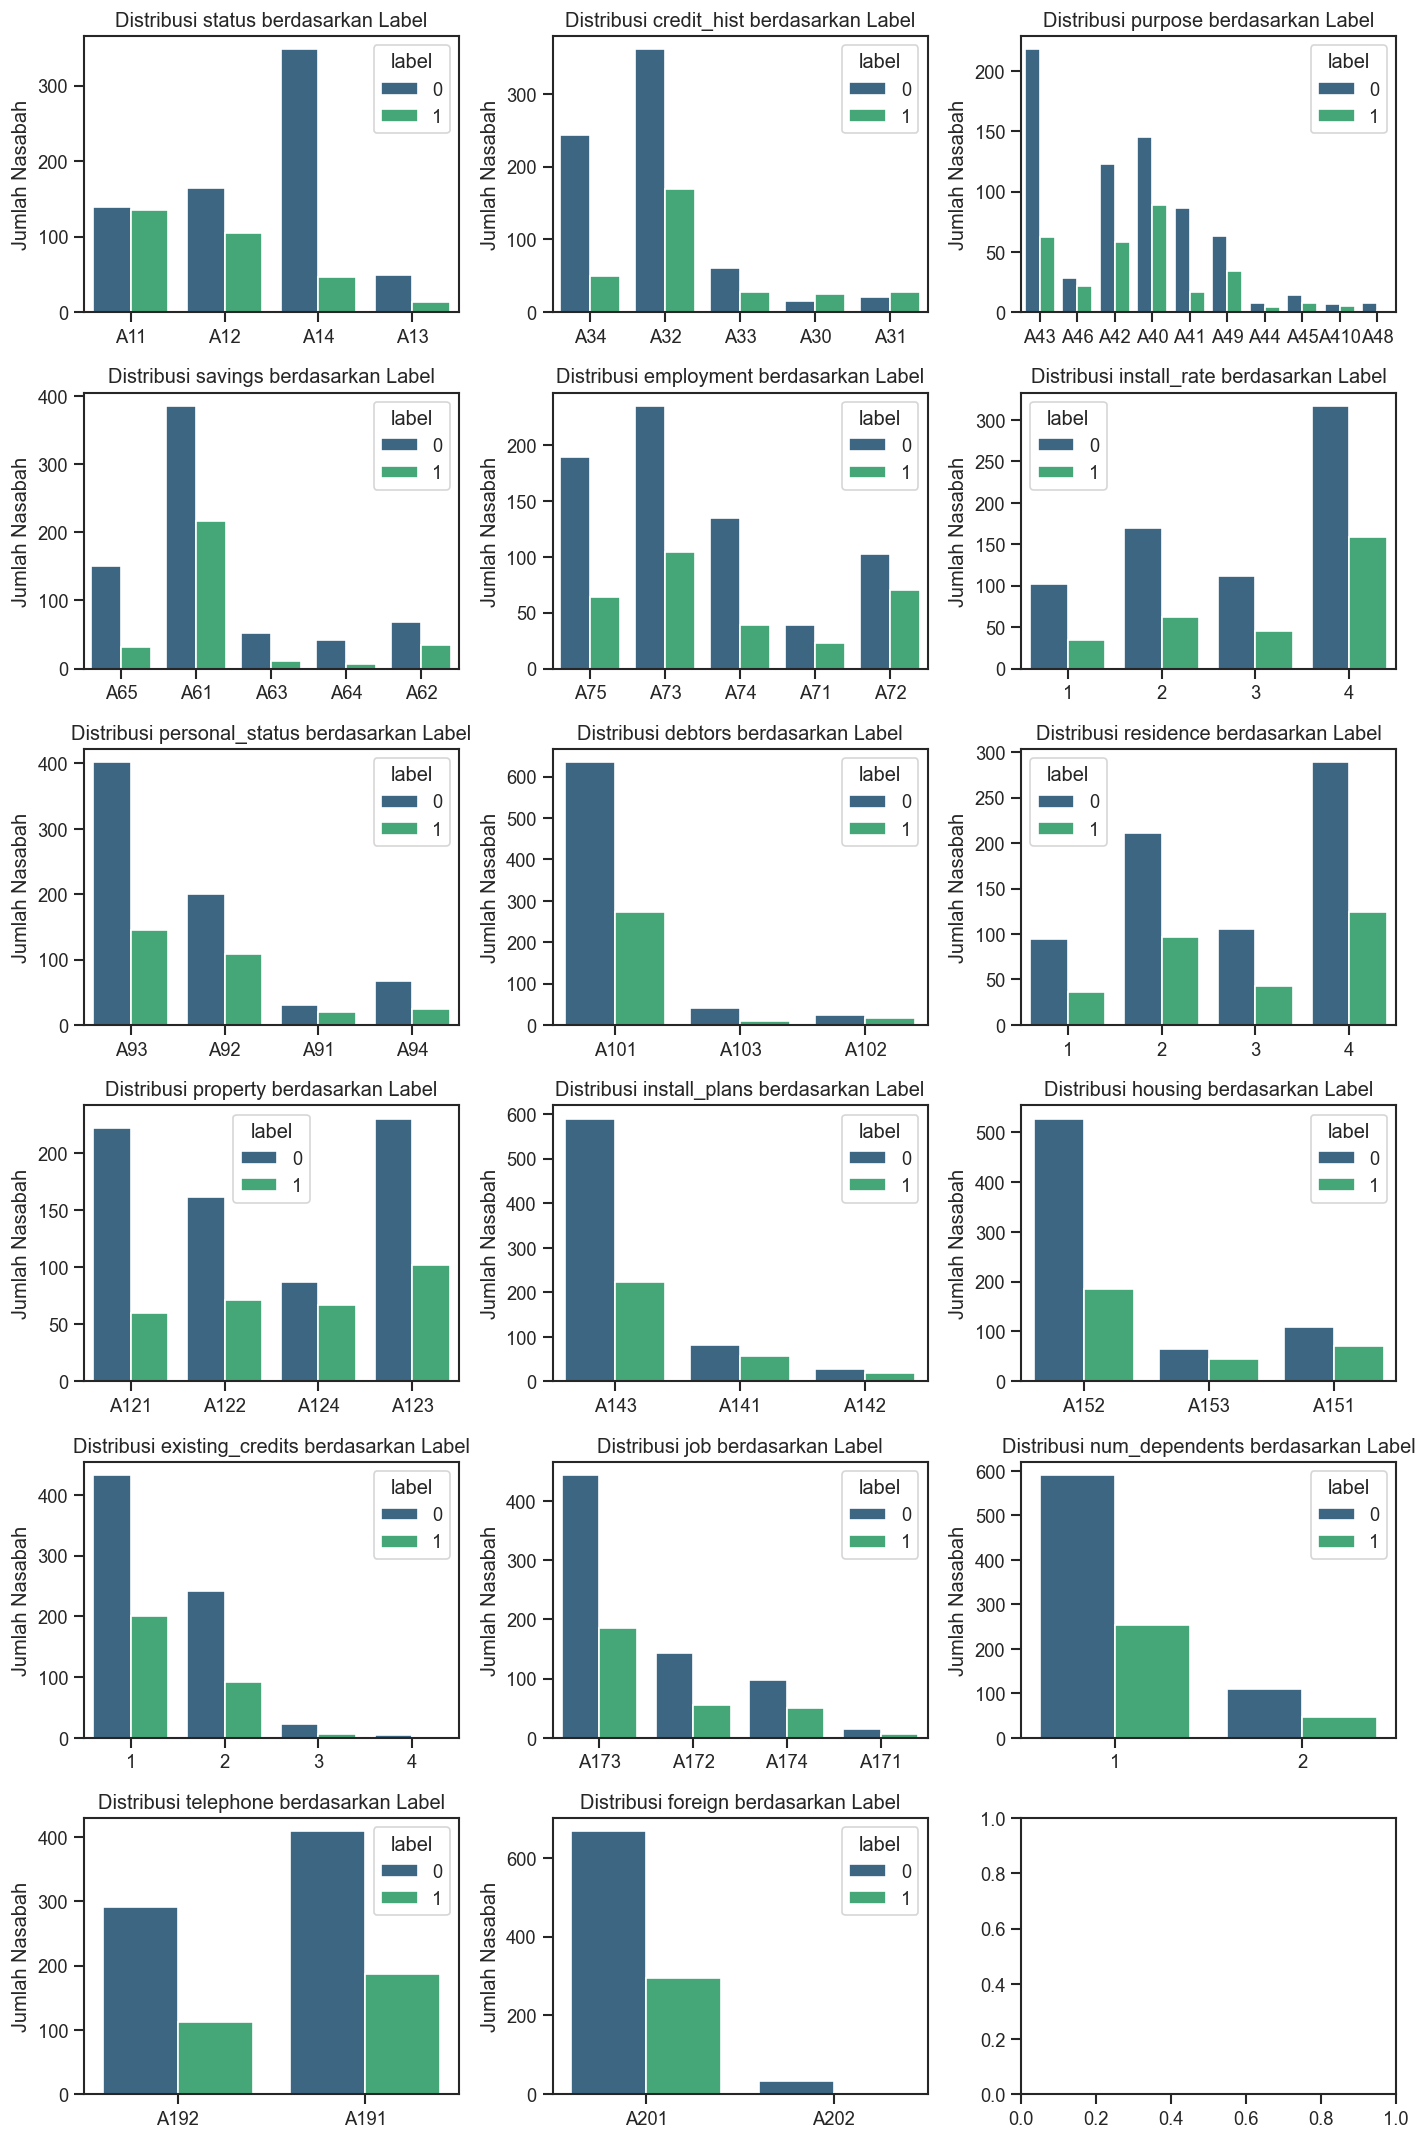

In [58]:
cat_filter = ['duration', 'amount', 'age', 'label']
cat_feat = df.drop(columns=cat_filter).columns.tolist()

fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(12, 18))
axes = axes.flatten()

for i, col in enumerate(cat_feat):
    sns.countplot(data=df, x=col, hue='label', ax=axes[i], palette='viridis')

    axes[i].set_title(f'Distribusi {col} berdasarkan Label')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Jumlah Nasabah')
plt.tight_layout()
plt.show()

### Uji Chi-Square

In [59]:
from scipy.stats import chi2_contingency

chi2_results = []

for col in cat_feat:
    contingency_table = pd.crosstab(df[col], df['label'])
    chi2, p, dof, _ = chi2_contingency(contingency_table)
    chi2_results.append({'feature': col, 'chi2': chi2, 'p_value': p})

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
print(chi2_df.to_string(index=False))

         feature       chi2      p_value
          status 123.720944 1.218902e-26
     credit_hist  61.691397 1.279187e-12
         savings  36.098928 2.761214e-07
        property  23.719551 2.858442e-05
         housing  18.199842 1.116747e-04
         purpose  33.356447 1.157491e-04
      employment  18.368274 1.045452e-03
   install_plans  12.839188 1.629318e-03
         foreign   5.821576 1.583075e-02
 personal_status   9.605214 2.223801e-02
         debtors   6.645367 3.605595e-02
    install_rate   5.476792 1.400333e-01
       telephone   1.172559 2.788762e-01
existing_credits   2.671198 4.451441e-01
             job   1.885156 5.965816e-01
       residence   0.749296 8.615521e-01
  num_dependents   0.000000 1.000000e+00


#### Fitur-fitur kurang diskriminatif

- `telephone` (p=0.28): distribusi cukup merata antar kelas
- `num_dependents` (p=1.00): hampir seluruh data bernilai 1, tidak ada variasi
- `residence` (p=0.86): distribusi relatif merata antar kelas
- `existing_credits` (p=0.45): mayoritas bernilai 1, variasi sangat sedikit
- `install_rate` (p=0.14): meskipun memiliki 4 kategori, secara statistik tidak berhubungan signifikan dengan label
- `job` (p=0.60): distribusi antar kelas tidak berbeda secara signifikan

In [60]:
# Dropping fitur-fitur kurang diskriminatif
cat_drop = ['telephone', 'num_dependents', 'residence', 'existing_credits']

Meskipun `install_rate` dan `job` memiliki p-value > 0.05, keduanya 
tetap dipertahankan. Training model Logistic Regression + WoE menunjukkan bahwa mendrop kedua fitur 
ini justru meningkatkan total cost dari 99 menjadi 103, mengindikasikan 
bahwa kontribusinya masih relevan dalam kombinasi dengan fitur lain.

# Feature Engineering

In [61]:
# Splitting Data
from sklearn.model_selection import train_test_split

X = df.drop(columns=['label'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [62]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Urutan kategori untuk fitur ordinal
status = ['A14', 'A11', 'A12', 'A13']
history = ['A34', 'A33', 'A30', 'A32', 'A31']
savings = ['A65', 'A61', 'A62', 'A63', 'A64']
employ = ['A71', 'A72', 'A73', 'A74', 'A75']
job = ['A171', 'A172', 'A173', 'A174']

ordinal_features = ['status', 'credit_hist', 'savings', 'employment', 'job']
ordinal_cat = [status, history, savings, employ, job]
nominal_features = [col for col in cat_feat if col not in ordinal_features and col not in cat_drop]

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

ordinal_transformer = OrdinalEncoder(
    categories=ordinal_cat,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

nominal_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cat),
        ('ord', ordinal_transformer, ordinal_features),
        ('nom', nominal_transformer, nominal_features),
    ],
    remainder='drop'
)


In [63]:
# WoE encoding
from category_encoders import WOEEncoder

cat_cols = [c for c in cat_feat if c not in cat_drop]
num_cols = num_cat

preprocessor_woe = ColumnTransformer(
    transformers=[
        ('woe', WOEEncoder(regularization=1e-9), cat_cols),
        ('scaler', StandardScaler(), num_cols)
    ]
)


## Cost-Matrix


Evaluasi model dalam proyek ini tidak menggunakan accuracy sebagai metrik utama.
Sebagai gantinya, digunakan **cost matrix** yang diambil langsung dari dokumentasi
resmi dataset German Credit (Prof. Hans Hofmann, Universität Hamburg):

|                  | Predicted: Good (0) | Predicted: Bad (1) |
|------------------|---------------------|--------------------|
| **Actual: Good (0)** | 0               | 1                  |
| **Actual: Bad (1)**  | 5               | 0                  |

Interpretasi:
- **False Positive (FP)** — nasabah *baik* diprediksi *buruk* → cost **1**
- **False Negative (FN)** — nasabah *buruk* diprediksi *baik* → cost **5**

Rasio 5:1 ini mencerminkan **meloloskan nasabah buruk
jauh lebih merugikan** dibandingkan menolak nasabah yang sebenarnya baik.
Nasabah yang gagal bayar berpotensi menyebabkan kerugian langsung (pokok +
bunga yang hilang), sementara menolak nasabah baik hanya berarti kehilangan
peluang bisnis.

Total cost dihitung sebagai:

$$\text{Total Cost} = (FP \times 1) + (FN \times 5)$$

Model terbaik adalah model dengan **total cost terendah**.

# Modelling

## Logistic Regression

### Baseline dengan Standar Feature Engineering (Standard Scaler, Ordinal, dan OHE)

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', l1_ratio=1, solver='liblinear', C=1, random_state=42))
])

baseline_pipe.fit(X_train, y_train)
y_pred = baseline_pipe.predict(X_test)
y_prob = baseline_pipe.predict_proba(X_test)[:, 1] >=0.5

print('Baseline')
print(confusion_matrix(y_test, y_prob))
print(classification_report(y_test, y_prob))

Baseline
[[96 45]
 [22 37]]
              precision    recall  f1-score   support

           0       0.81      0.68      0.74       141
           1       0.45      0.63      0.52        59

    accuracy                           0.67       200
   macro avg       0.63      0.65      0.63       200
weighted avg       0.71      0.67      0.68       200



#### Optimisasi dengan GridSearchCV

In [65]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', 
        l1_ratio=1, 
        solver='liblinear', 
        C=1, 
        max_iter=5000  # <--- Tambahkan ini
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def credit_cost_loss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # FP pinalti 5, FN pinalti 1
    total_cost = (fn * 5) + (fp * 1)
    return total_cost

cost_scorer = make_scorer(credit_cost_loss, greater_is_better=False)

param_grid = [
    {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear'],
        'classifier__class_weight': ['balanced']
    },
    # l1_ratio
    {
        'classifier__l1_ratio': [1],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['saga'],
        'classifier__class_weight': ['balanced'],
    }
]


grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=skf, scoring=cost_scorer )
grid_search.fit(X_train, y_train)

print("Parameter Terbaik:", grid_search.best_params_)

Parameter Terbaik: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__solver': 'liblinear'}


#### Training ulang model

In [66]:

baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear', C=0.1))
])

baseline_pipe.fit(X_train, y_train)
y_pred = baseline_pipe.predict(X_test)
y_prob = baseline_pipe.predict_proba(X_test)[:, 1] >=0.5

print('Optimisasi Baseline')
print(confusion_matrix(y_test, y_prob))
print(classification_report(y_test, y_prob))

Optimisasi Baseline
[[99 42]
 [24 35]]
              precision    recall  f1-score   support

           0       0.80      0.70      0.75       141
           1       0.45      0.59      0.51        59

    accuracy                           0.67       200
   macro avg       0.63      0.65      0.63       200
weighted avg       0.70      0.67      0.68       200



### Weight of Evidence (WoE)

WoE merepresentasikan seluruh kelas dalam satu fitur sebagai satu nilai numerik yang mengandung informasi terhadap risiko dengan persamaan:

$$
WoE = \ln (\frac{\% Bad}{\% Good})
$$

Logistic regression cukup mempelajari satu koefisien per fitur sehingga lebih stabil pada dataset berukuran kecil.

#### Optimisasi dengan GridSearchCV

In [67]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold


pipe = Pipeline([
    ('preprocessor', preprocessor_woe),
    ('classifier', LogisticRegression(
        class_weight='balanced', 
        l1_ratio=1, 
        solver='liblinear', 
        C=1, 
        max_iter=5000
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=skf, scoring=cost_scorer )
grid_search.fit(X_train, y_train)

print("Parameter Terbaik:", grid_search.best_params_)

Parameter Terbaik: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__solver': 'liblinear'}


### Training ulang

In [68]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_woe),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear', C=10))
])

pipeline.fit(X_train, y_train)

y_pred_proba_lr = pipeline.predict_proba(X_test)[:, 1]
y_pred_woe = (y_pred_proba_lr >= 0.5).astype(int)

print('Optimisasi model dengan WoE')
print(confusion_matrix(y_test, y_pred_woe))
print(classification_report(y_test, y_pred_woe))

Optimisasi model dengan WoE
[[102  39]
 [ 12  47]]
              precision    recall  f1-score   support

           0       0.89      0.72      0.80       141
           1       0.55      0.80      0.65        59

    accuracy                           0.74       200
   macro avg       0.72      0.76      0.72       200
weighted avg       0.79      0.74      0.76       200



### Feature Importance

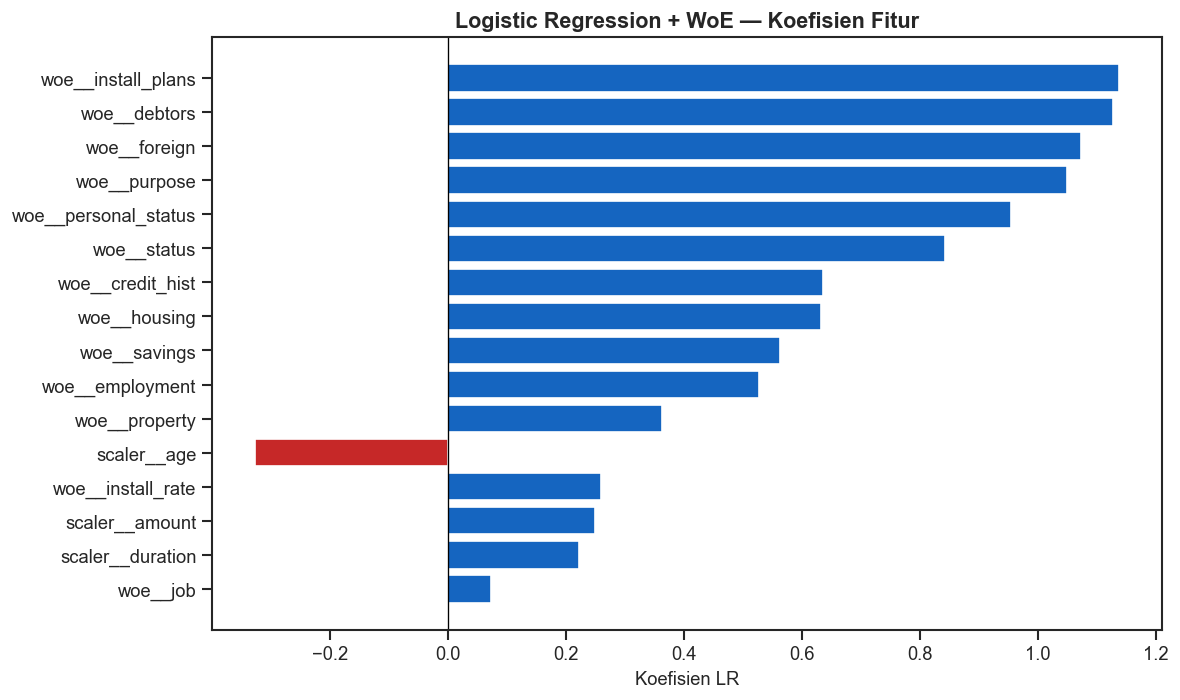

In [69]:


coef_values = pipeline.named_steps['classifier'].coef_[0]  
feature_names_woe = X_train.columns.tolist()          

coef_df = pd.DataFrame({
    'Feature': pipeline.named_steps['preprocessor'].get_feature_names_out(),
    'Coefficient': coef_values
})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1565C0' if c > 0 else '#C62828' for c in coef_df['Coefficient'][::-1]]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Koefisien LR', fontsize=11)
ax.set_title('Logistic Regression + WoE — Koefisien Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:

# Get WOE mappings from the encoder
woe_encoder = pipeline.named_steps['preprocessor'].named_transformers_['woe']
pd.DataFrame(woe_encoder.mapping)

,status,credit_hist,purpose,savings,employment,personal_status,debtors,property,install_plans,housing,job,foreign
-2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.803965,0.000569,0.241731,0.223241,-0.379862,-0.197541,0.013818,0.596230,-0.115848,-0.231825,0.008159,0.033227
2,-0.519624,-0.768085,0.787285,-0.684704,0.385877,0.361779,0.235217,0.086214,0.526859,0.465563,0.229174,-1.278911
3,-1.032237,0.094138,-0.605566,-0.495345,0.063648,0.275545,-0.439581,0.009206,0.315259,0.587118,-0.239560,NaN
4,0.384996,1.491940,0.391827,0.238356,-0.182459,-0.045951,NaN,-0.544942,NaN,NaN,-0.034116,NaN
5,NaN,1.159806,-0.495886,-1.075570,0.389367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,0.025145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,0.068163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,0.281737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- `install_plans` dan `debtors` memiliki koefisien tertinggi, sehingga model sangat mengandalkan kedua fitur ini untuk memprediksi nasabah buruk
- `status` dan `credit_hist` meskipun secara teori paling penting dalam credit scoring, berada di posisi tengah. Hal ini kemungkinan disebabkan perbedaan rentang nilai WoE antar fitur
- `age` memiliki koefisien negatif, mengindikasikan usia lebih tua dengan risiko yang lebih rendah untuk gagal bayar.
- `job` memiliki pengaruh paling kecil, konsisten dengan temuan sebelumnya bahwa fitur ini tidak signifikan secara statistik

## Random Forest

### Baseline

In [71]:
from sklearn.ensemble import RandomForestClassifier
baseline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))
])

baseline_rf.fit(X_train, y_train)

y_pred_proba = baseline_rf.predict_proba(X_test)[:, 1]
y_pred_woe = (y_pred_proba >= 0.5).astype(int)

print('Baseline RF')
print(confusion_matrix(y_test, y_pred_woe))
print(classification_report(y_test, y_pred_woe))

Baseline RF
[[130  11]
 [ 38  21]]
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       141
           1       0.66      0.36      0.46        59

    accuracy                           0.76       200
   macro avg       0.72      0.64      0.65       200
weighted avg       0.74      0.76      0.73       200



#### Optimisasi dengan GridSearchCV

In [72]:
param_grid = {
    'classifier__max_depth': [5, 7, 10],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_features': [5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__random_state': [42]
}

grid_search = GridSearchCV(baseline_rf, param_grid, cv=skf, scoring=cost_scorer )
grid_search.fit(X_train, y_train)

print("Parameter Terbaik:", grid_search.best_params_)

Parameter Terbaik: {'classifier__max_depth': 5, 'classifier__max_features': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200, 'classifier__random_state': 42}


In [73]:
baseline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300,random_state=42, class_weight='balanced', max_depth=5, max_features=10, min_samples_leaf=4, min_samples_split=2))
])

baseline_rf.fit(X_train, y_train)

y_pred_proba_rf = baseline_rf.predict_proba(X_test)[:, 1]
y_pred_woe = (y_pred_proba_rf >= 0.5).astype(int)

print('Optimisasi model RF')
print(confusion_matrix(y_test, y_pred_woe))
print(classification_report(y_test, y_pred_woe))

Optimisasi model RF
[[98 43]
 [15 44]]
              precision    recall  f1-score   support

           0       0.87      0.70      0.77       141
           1       0.51      0.75      0.60        59

    accuracy                           0.71       200
   macro avg       0.69      0.72      0.69       200
weighted avg       0.76      0.71      0.72       200



### Feature Importances

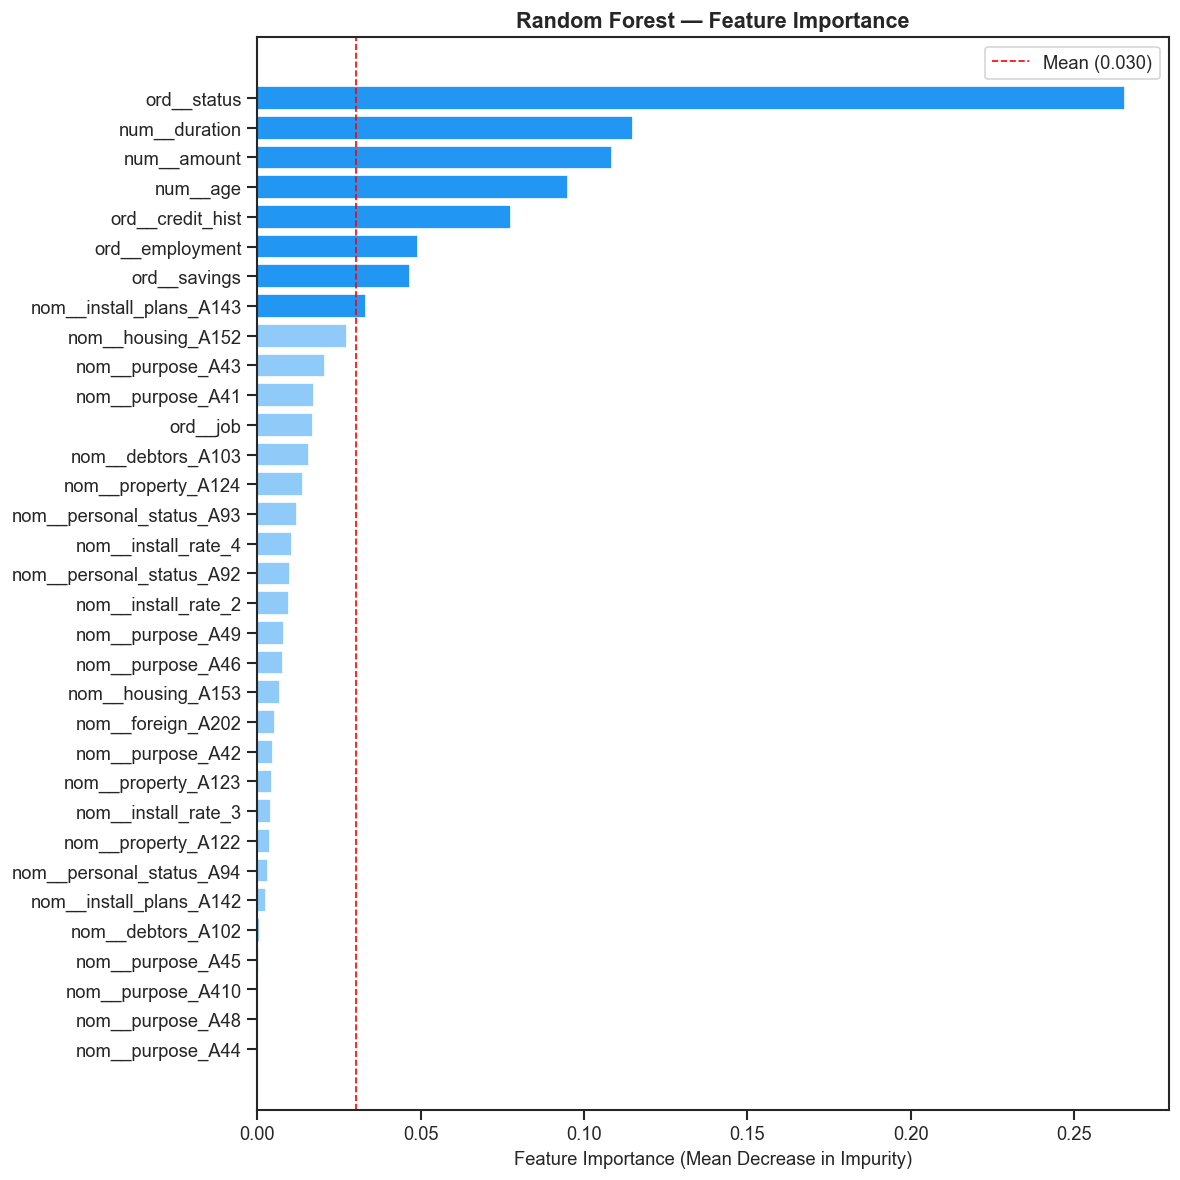

In [74]:
import matplotlib.pyplot as plt
import numpy as np

best_rf = grid_search.best_estimator_

feature_names = X_train.columns.tolist()
importances = best_rf.named_steps['classifier'].feature_importances_

# Sorting
sorted_idx = np.argsort(importances)[::-1]
sorted_importances = importances[sorted_idx]
preproc = best_rf.named_steps['preprocessor']
try:
    transformed_names = preproc.get_feature_names_out()
except Exception:
    transformed_names = preproc.get_feature_names_out(X_train.columns)
sorted_features = [transformed_names[i] for i in sorted_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2196F3' if imp > np.mean(importances) else '#90CAF9' for imp in sorted_importances]
bars = ax.barh(sorted_features[::-1], sorted_importances[::-1], color=colors[::-1])

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.axvline(np.mean(importances), color='red', linestyle='--', linewidth=1, label=f'Mean ({np.mean(importances):.3f})')
ax.legend()

plt.tight_layout()
plt.show()

#### Interpretasi Feature Importance

Fitur dengan importance di atas rata-rata (garis merah putus-putus) adalah
kontributor utama dalam keputusan model RF:

- `status` dan `credit_hist` mendominasi — konsisten dengan hasil chi-square
  yang menunjukkan keduanya paling signifikan secara statistik.
- `amount` dan `duration` (fitur numerik) juga berkontribusi besar,
  mengkonfirmasi temuan point-biserial correlation di tahap EDA.
- Fitur seperti `job` dan `install_rate` meskipun p-value chi-square > 0.05,
  tetap muncul dengan importance non-trivial — ini menjelaskan mengapa
  mendrop keduanya justru meningkatkan total cost.

> **Catatan:** Feature importance berbasis MDI (Mean Decrease in Impurity)
> cenderung bias terhadap fitur dengan banyak kategori atau kardinalitas tinggi.
> Untuk interpretasi yang lebih robust, permutation importance atau SHAP
> dapat dipertimbangkan sebagai pengembangan selanjutnya.

# Evaluasi dan Perbandingan

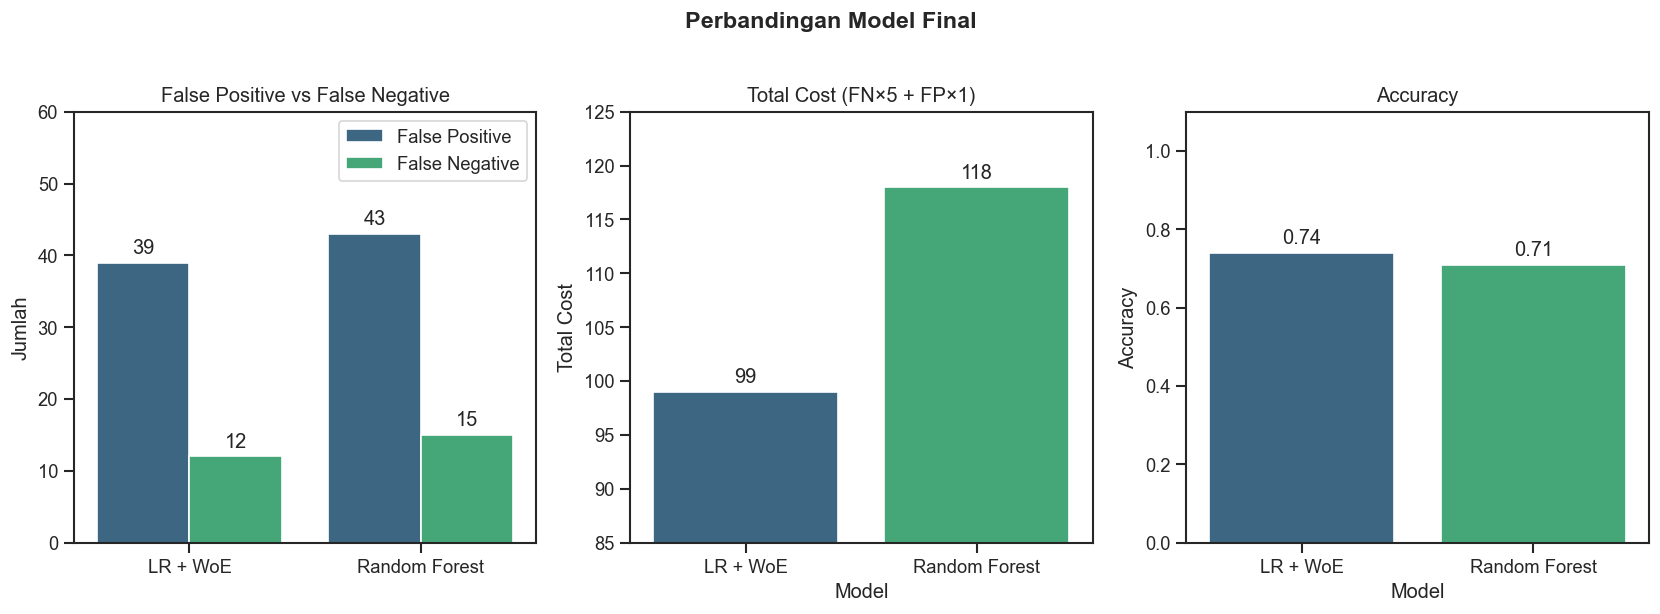

In [77]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Data hasil akhir ---
models = ['LR + WoE', 'Random Forest']
fp_vals = [39, 43]
fn_vals = [12, 15]
cost_vals = [99, 118]
acc_vals = [0.74, 0.71]

x = np.arange(len(models))
width = 0.35
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Perbandingan Model Final', fontsize=14, fontweight='bold', y=1.02)

# Plot 1: FP vs FN
fp_fn_data = pd.DataFrame({
    'Model': models * 2,
    'Jumlah': fp_vals + fn_vals,
    'Tipe': ['False Positive'] * 2 + ['False Negative'] * 2
})
sns.barplot(data=fp_fn_data, x='Model', y='Jumlah', hue='Tipe', ax=axes[0], palette='viridis')
axes[0].set_title('False Positive vs False Negative')
axes[0].set_ylabel('Jumlah')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 60)
axes[0].legend(loc='upper right', bbox_to_anchor=(1, 1))
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

# Plot 2: Total Cost
cost_data = pd.DataFrame({'Model': models, 'Total Cost': cost_vals})  # ← tambah ini
sns.barplot(data=cost_data, x='Model', y='Total Cost', hue='Model', legend=False, ax=axes[1], palette='viridis')
axes[1].set_title('Total Cost (FN×5 + FP×1)')
axes[1].set_ylabel('Total Cost')
axes[1].set_ylim(85, 125)
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

# Plot 3: Accuracy
acc_data = pd.DataFrame({'Model': models, 'Accuracy': acc_vals})  # ← tambah ini
sns.barplot(data=acc_data, x='Model', y='Accuracy', hue='Model', legend=False, ax=axes[2], palette='viridis')
axes[2].set_title('Accuracy')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1.1)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

In [76]:
import pandas as pd

progression_data = {
    'Tahap': [
        'Baseline (Ordinal+OHE)',
        '+ GridSearch (Ordinal+OHE)',
        '+ WoE Encoding',
        'Baseline',
        '+ GridSearch Penuh',
    ],
    'Model': [
        'Logistic Regression', 'Logistic Regression', 'Logistic Regression',
        'Random Forest', 'Random Forest'
    ],
    'FP': [45, 42, 39, 11, 43],
    'FN': [22, 24, 12, 38, 15],
    'Total Cost': [155, 162, 99, 201, 118]
}

df_prog = pd.DataFrame(progression_data)
df_prog

,Tahap,Model,FP,FN,Total Cost
0,Baseline (Ordinal+OHE),Logistic Regression,45,22,155
1,+ GridSearch (Ordinal+OHE),Logistic Regression,42,24,162
2,+ WoE Encoding,Logistic Regression,39,12,99
3,Baseline,Random Forest,11,38,201
4,+ GridSearch Penuh,Random Forest,43,15,118


### Analisis Per Model

#### Logistic Regression

**Logistic Regression + WoE** menunjukkan perbaikan total cost yang konsisten dan bertahap di setiap tahap optimasi. Kontribusi terbesar berasal dari transisi Ordinal+OHE ke WoE encoding yang menurunkan cost sebesar 56 poin (dari 155 ke 99). Hal ini mengkonfirmasi bahwa representasi fitur kategorikal berbasis information value lebih efektif menangkap sinyal dibanding encoding konvensional. GridSearch dengan `class_weight='balanced'` justru menaikkan total cost sebesar 7 poin, mengindikasikan bahwa kualitas representasi fitur jauh lebih dominan dibanding tuning hyperparameter dalam kasus ini.

#### Random Forest

**Random Forest (RF)** menunjukkan pola yang berbeda, baseline-nya justru terburuk (cost 201) karena `class_weight='balanced'` belum cukup agresif menghukum default. Setelah GridSearch, model membaik drastis dengan cost turun ke 118 — FN turun dari 38 ke 15, namun FP melonjak dari 11 ke 43. Ini mengindikasikan bahwa bottleneck utama RF ada pada class weight, bukan arsitektur modelnya.

### Interpretasi Trade-off

Kedua model menunjukkan total cost yang berbeda (99 vs 109) dengan karakteristik error yang hampir mirip:

| | LR + WoE | Random Forest |
|---|---|---|
| **False Positive** | 39 (28% nasabah baik ditolak) | 43 (30% nasabah baik ditolak) |
| **False Negative** | 12 (nasabah buruk lolos) | 15 (nasabah buruk lolos) |
| **Total Cost** | 99 | 118 |
| **Accuracy** | 0.74 | 0.71 |

 LR berhasil menangkap 3 nasabah buruk lebih banyak dibanding RF, yang dalam cost matrix bernilai 15 poin (3 × 5). LR + WoE menjadi pilihan yang lebih unggul baik dari sisi cost maupun accuracy.


# Kesimpulan

Proyek ini menunjukkan bahwa dalam konteks kredit scoring, pemilihan model tidak cukup berdasarkan accuracy, total cost berbasis business metric harus menjadi kriteria utama evaluasi. LR + WoE mencapai cost lebih rendah (99) dibandingkan Random Forest (118), dengan accuracy yang juga lebih tinggi (0.74 vs 0.71).

Simpulan hasil proyek:
1. WoE encoding adalah kontributor terbesar penurunan cost pada LR, jauh melampaui kontribusi tuning hyperparameter (56 poin). Ini mengindikasikan bahwa kualitas representasi fitur lebih krusial dari kompleksitas model dalam kasus ini.
2. Chi-square mengkonfirmasi keputusan feature selection visual, sekaligus mengungkapkan bahwa install_rate dan job meskipun tidak signifikan secara individual, tetap berkontribusi dalam kombinasi fitur.
3. Dengan `class_weight='balanced'`, kedua model menghasilkan FP yang identik — perbedaan performa akhir sepenuhnya ditentukan oleh kemampuan masing-masing model menangkap nasabah buruk (FN), di mana LR + WoE terbukti lebih unggul.

# Saran

1. Eksplorasi model berbasis boosting belum dilakukan dan berpotensi menghasilkan keseimbangan FP-FN yang lebih baik
2. Dataset terbatas pada 1000 sampel; performa kedua model perlu divalidasi pada data yang lebih besar dan beragam